In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image



In [ ]:
!unzip '/content/drive/MyDrive/gi.zip'

Archive:  /content/drive/MyDrive/gi.zip
  inflating: Garbage classification/Garbage classification/cardboard/cardboard1.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard10.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard100.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard101.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard102.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard103.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard104.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard105.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard106.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard107.jpg  
  inflating: Garbage classification/Garbage classification/cardboard/cardboard108.j

In [11]:
os.listdir("/content")

['.config',
 'one-indexed-files-notrash_train.txt',
 'one-indexed-files.txt',
 'zero-indexed-files.txt',
 'Garbage classification',
 'garbage classification',
 'one-indexed-files-notrash_val.txt',
 'one-indexed-files-notrash_test.txt',
 'drive',
 'sample_data']

In [12]:
import os
os.listdir("/content/garbage classification/Garbage classification")

['plastic', 'metal', 'glass', 'trash', 'cardboard', 'paper']

In [17]:
train_path="/content/garbage classification/Garbage classification"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,            # normalization
    validation_split=0.2,      # 80 train / 20 validation

    # augmentation
    rotation_range=60,
    zoom_range=0.5,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [18]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),   # resizing
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 2024 images belonging to 6 classes.


In [19]:
val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 503 images belonging to 6 classes.


In [20]:
import os
print(os.listdir("/content"))

['.config', 'one-indexed-files-notrash_train.txt', 'one-indexed-files.txt', 'zero-indexed-files.txt', 'Garbage classification', 'garbage classification', 'one-indexed-files-notrash_val.txt', 'one-indexed-files-notrash_test.txt', 'drive', 'sample_data']


EDA

Show number of images per class

In [11]:
print(train_data.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


Count images in each class

In [ ]:
import numpy as np
counts=np.bincount(train_data.classes)
print(counts)

[323 401 328 476 386 110]


Display sample images

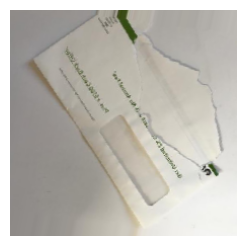

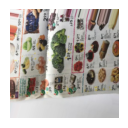

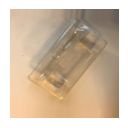

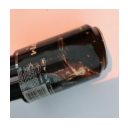

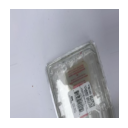

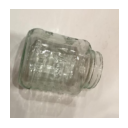

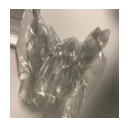

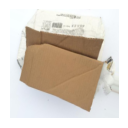

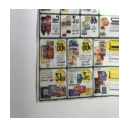

In [ ]:
import matplotlib.pyplot as plt
images,labels=next(train_data)
plt.figure(figsize=(10,10))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(images[i])
  plt.axis('off')
  plt.show()

In [21]:
class_weight = {
    0: 1.0,
    1: 0.8,
    2: 1.0,
    3: 0.7,
    4: 0.8,
    5: 3.0   # important (minority class)
}

Model Development

Using Tranfer Learning(MobileNetV2)
It is pre trained model (already learned from millions of images)

Load Pre-trained Model

In [12]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze base layer

In [13]:
base_model.trainable=False

Add custom layers

In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

Compile Model

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

step:5 Model Training

In [16]:
history =model.fit(train_data,validation_data=val_data,class_weight=class_weight,epochs=20)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.6502 - loss: 0.9258 - val_accuracy: 0.6740 - val_loss: 0.8567
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.7673 - loss: 0.5785 - val_accuracy: 0.6859 - val_loss: 0.7651
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8009 - loss: 0.5156 - val_accuracy: 0.7217 - val_loss: 0.7951
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.8246 - loss: 0.4622 - val_accuracy: 0.6879 - val_loss: 0.8653
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8409 - loss: 0.4118 - val_accuracy: 0.7137 - val_loss: 0.7859
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.8582 - loss: 0.3503 - val_accuracy: 0.7356 - val_loss: 0.7749
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8765 - loss: 0.3148 - val_accuracy: 0.7316 - val_loss: 0.7532
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.8715 - loss: 0.3190 - val_accuracy: 0.7575 - v

Saving the trained model

In [17]:
model.save('/content/drive/MyDrive/my_model1.keras')

In [18]:
import joblib
joblib.dump(train_data.class_indices,'/content/drive/MyDrive/class_names.pkl')

['/content/drive/MyDrive/class_names.pkl']

In [22]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/my_model1.keras')

step 6:Model Evaluation

In [23]:
loss, accuracy = model.evaluate(val_data)
print("Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7674 - loss: 0.7324
Accuracy: 0.7673956155776978
